In [16]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
BASE_DIR = r"E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new"
CANCER_DIR = r"E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER"
NORMAL_DIR = r"E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\riskfree"


In [18]:
def extract_color_features(image_path):
    img = cv2.imread(image_path)

    # SAFETY CHECK
    if img is None:
        print("❌ Skipping unreadable file:", image_path)
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)

    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    return {
        "R_mean": np.mean(r),
        "R_std": np.std(r),
        "G_mean": np.mean(g),
        "G_std": np.std(g),
        "B_mean": np.mean(b),
        "B_std": np.std(b),
        "H_mean": np.mean(h),
        "H_std": np.std(h),
        "S_mean": np.mean(s),
        "S_std": np.std(s),
        "V_mean": np.mean(v),
        "V_std": np.std(v),
    }


In [19]:
records = []

for img_file in os.listdir(CANCER_DIR):
    if img_file.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(CANCER_DIR, img_file)

        features = extract_color_features(path)
        if features is None:
            continue   # skip broken images

        features["label"] = "risk"
        records.append(features)

for img_file in os.listdir(NORMAL_DIR):
    if img_file.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(NORMAL_DIR, img_file)

        features = extract_color_features(path)
        if features is None:
            continue

        features["label"] = "normal"
        records.append(features)


❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\101.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\200.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\273.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\317.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\328.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\407.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\450.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\455.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\481.jpeg
❌ Skipping unreadable file: E:\ec300\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\485.jpeg


In [21]:
df = pd.DataFrame(records)
df.head()

,R_mean,R_std,G_mean,G_std,B_mean,B_std,H_mean,H_std,S_mean,S_std,V_mean,V_std,label
0,151.348587,55.125286,130.165558,49.328415,131.088531,48.128521,75.451132,77.051167,45.718763,37.178692,152.264634,53.865409,risk
1,156.472809,87.814148,104.464111,78.491402,105.890556,75.803230,83.812979,84.011589,83.018014,63.384506,156.651585,87.589264,risk
2,177.489426,33.353333,108.552231,49.084694,101.153709,43.304535,31.747178,61.397860,117.216254,42.179760,178.598589,34.764935,risk
3,178.493973,52.281776,130.319473,47.285072,131.233185,45.982182,83.774181,83.438194,73.516045,35.352489,179.198728,50.982487,risk
4,176.969376,54.940979,134.843811,42.259830,139.322968,51.426567,77.407746,78.430530,70.695242,32.089871,181.142914,53.898892,risk


In [23]:
df["label"].value_counts()


label
risk      490
normal    450
Name: count, dtype: int64

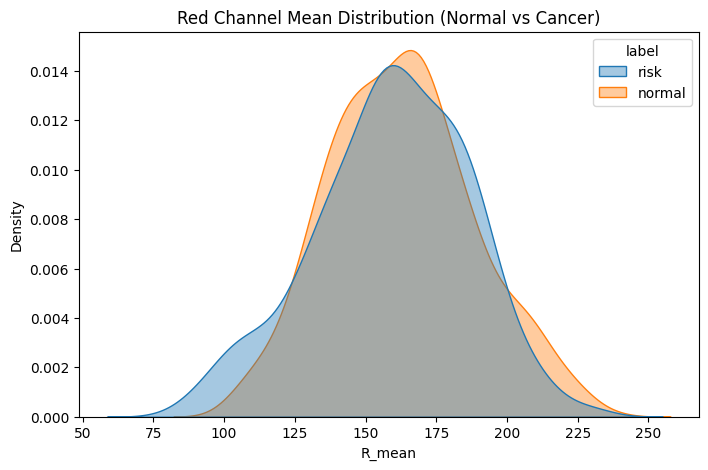

In [24]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="R_mean",
    hue="label",
    fill=True,
    common_norm=False,
    alpha=0.4
)
plt.title("Red Channel Mean Distribution (Normal vs Cancer)")
plt.show()


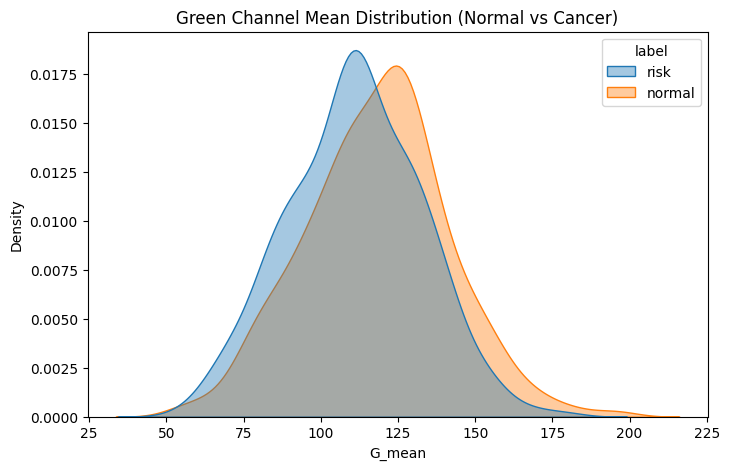

In [25]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="G_mean",
    hue="label",
    fill=True,
    common_norm=False,
    alpha=0.4
)
plt.title("Green Channel Mean Distribution (Normal vs Cancer)")
plt.show()


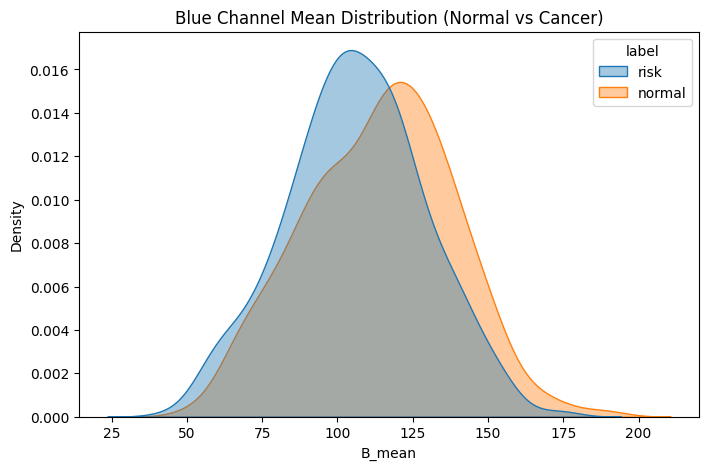

In [26]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="B_mean",
    hue="label",
    fill=True,
    common_norm=False,
    alpha=0.4
)
plt.title("Blue Channel Mean Distribution (Normal vs Cancer)")
plt.show()


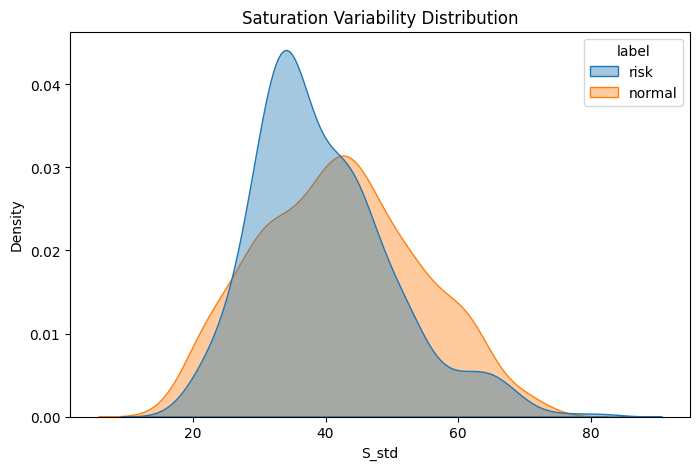

In [27]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="S_std",
    hue="label",
    fill=True,
    common_norm=False,
    alpha=0.4
)
plt.title("Saturation Variability Distribution")
plt.show()


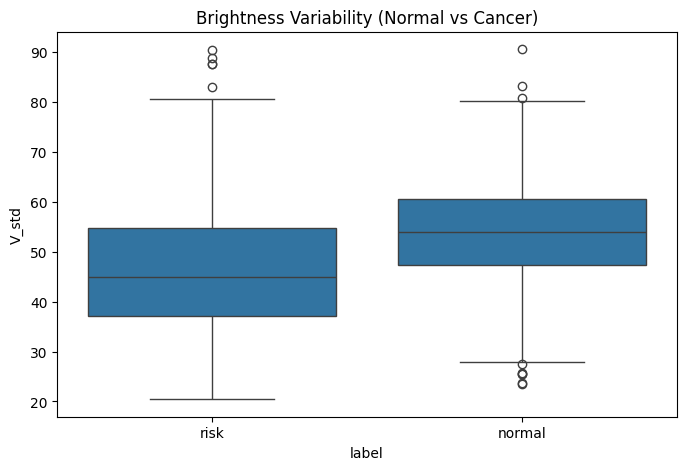

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="label",
    y="V_std"
)
plt.title("Brightness Variability (Normal vs Cancer)")
plt.show()

p-value: 0.0005458813783961843
